# Predicting NBA Wins Using Team Statistics

**Author:** Shaheer Malik

**Team:** Individual

## Problem
This project investigates how NBA team statistics can predict the number of wins in a season.

## Dataset
The dataset contains NBA team statistics from multiple NBA seasons.

## Dataset Source
https://www.kaggle.com/datasets/mharvnek/nba-team-stats-00-to-18

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split

# Load dataset
NBA_data = pd.read_csv('/content/drive/My Drive/Colab Notebooks/nba_team_stats_00_to_23.csv')

In [28]:
print("Dataset Shape:")
print(NBA_data.shape)

Dataset Shape:
(716, 29)


The dataset contains NBA team statistics from many seasons. Each row represents one NBA team in one season.

In [29]:
NBA_data["ppg"] = NBA_data["points"] / NBA_data["games_played"]
NBA_data["tpg"] = NBA_data["turnovers"] / NBA_data["games_played"]
NBA_data["fg_pct"] = NBA_data["field_goals_made"] / NBA_data["field_goals_attempted"]

New variables were created to better compare team performance statistics.

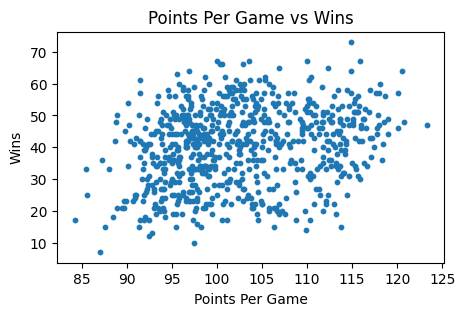

In [30]:
plt.figure(figsize=(5,3))
plt.scatter(NBA_data["ppg"], NBA_data["wins"], s=10)

plt.xlabel("Points Per Game")
plt.ylabel("Wins")
plt.title("Points Per Game vs Wins")

plt.show()

Teams that score more points generally win more games.

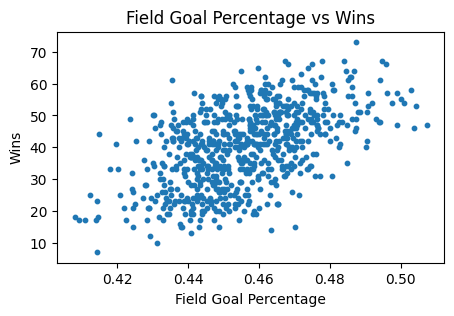

In [31]:
plt.figure(figsize=(5,3))
plt.scatter(NBA_data["fg_pct"], NBA_data["wins"], s=10)

plt.xlabel("Field Goal Percentage")
plt.ylabel("Wins")
plt.title("Field Goal Percentage vs Wins")

plt.show()

Shooting efficiency also has a positive relationship with wins.

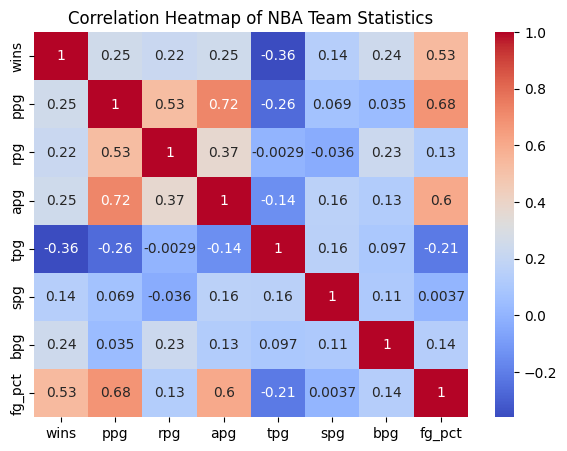

In [32]:
NBA_data["rpg"] = NBA_data["rebounds"] / NBA_data["games_played"]
NBA_data["apg"] = NBA_data["assists"] / NBA_data["games_played"]
NBA_data["spg"] = NBA_data["steals"] / NBA_data["games_played"]
NBA_data["bpg"] = NBA_data["blocks"] / NBA_data["games_played"]

heatmap_data = NBA_data[["wins", "ppg", "rpg", "apg", "tpg", "spg", "bpg", "fg_pct"]]

corr_matrix = heatmap_data.corr()

plt.figure(figsize=(7,5))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm")

plt.title("Correlation Heatmap of NBA Team Statistics")
plt.show()

The heatmap shows how different team statistics relate to wins and to each other.

In [33]:
X = NBA_data[["ppg", "rpg", "apg", "tpg", "spg", "bpg"]]
y = NBA_data["wins"]

model = LinearRegression()
model.fit(X, y)

print("Linear Regression R^2 Score:", round(model.score(X, y), 3))

Linear Regression R^2 Score: 0.271


Linear regression was used to predict wins using multiple team statistics.

In [34]:
X = NBA_data[["ppg", "rpg", "apg", "tpg", "spg", "bpg", "fg_pct"]]
y = NBA_data["wins"]

model = LinearRegression()
model.fit(X, y)

improved_score = model.score(X, y)

print("Improved Linear Regression R^2 Score:", round(improved_score, 3))

Improved Linear Regression R^2 Score: 0.578


Adding shooting efficiency improved the model’s prediction accuracy.

In [35]:
tree_model = DecisionTreeRegressor(max_depth=5, random_state=1)
tree_model.fit(X, y)

tree_score = tree_model.score(X, y)

print("Decision Tree R^2 Score:", round(tree_score, 3))

Decision Tree R^2 Score: 0.561


A decision tree regression model was also tested to compare performance.

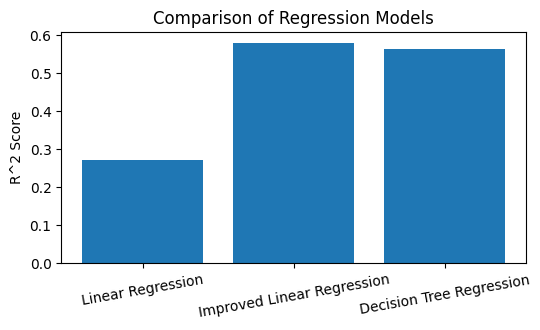

In [36]:
model_comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Improved Linear Regression", "Decision Tree Regression"],
    "R^2 Score": [0.271, improved_score, tree_score]
})

plt.figure(figsize=(6,3))
plt.bar(model_comparison["Model"], model_comparison["R^2 Score"])

plt.ylabel("R^2 Score")
plt.title("Comparison of Regression Models")

plt.xticks(rotation=10)
plt.show()

Comparing multiple models helps determine which method predicts wins more accurately.

In [37]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=1
)

model = LinearRegression()
model.fit(X_train, y_train)

test_score = model.score(X_test, y_test)

print("Linear Regression Test R^2 Score:", round(test_score, 3))

Linear Regression Test R^2 Score: 0.534


The train-test split helps evaluate model performance on unseen data.

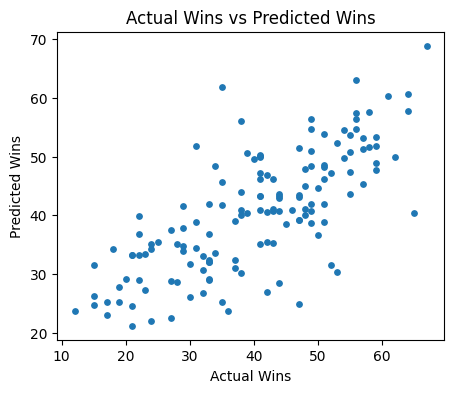

In [38]:
predictions = model.predict(X_test)

plt.figure(figsize=(5,4))
plt.scatter(y_test, predictions, s=15)

plt.xlabel("Actual Wins")
plt.ylabel("Predicted Wins")

plt.title("Actual Wins vs Predicted Wins")

plt.show()

The graph compares the predicted wins to the actual wins from the testing data.

## Conclusion

Using multiple NBA team statistics improved the ability to predict wins.

The results showed that scoring alone does not fully explain team success.

Adding statistics like rebounds, assists, turnovers, steals, blocks, and shooting efficiency created a more accurate model.

Overall, the project demonstrated how machine learning can be used to analyze sports data and predict NBA team success.

## Future Work

In the future, more advanced statistics and additional machine learning models could be explored to improve prediction accuracy.

## Team Contribution

This project was completed individually by myself.

## GitHub Repository

https://github.com/Shaheer-Malik/CSC-108-Final-Project